In [1]:
import torch
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import torch.nn as nn
from torchvision.models import resnet18, ResNet18_Weights
import matplotlib.pyplot as plt
import os
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import numpy as np


In [2]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)


Using device: cpu


In [3]:
BASE_DIR = r"C:\Users\nshre\OneDrive\Desktop\Vision-Based-Fake-Medicine-Detection\dataset"

test_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

test_dataset = datasets.ImageFolder(
    root=os.path.join(BASE_DIR, "Test"),
    transform=test_transform
)

test_loader = DataLoader(test_dataset, batch_size=16, shuffle=False)
class_names = test_dataset.classes
print("Classes:", class_names)


Classes: ['Fake', 'Real']


In [4]:
model = resnet18(weights=ResNet18_Weights.DEFAULT)

# Replace final layer
model.fc = nn.Linear(model.fc.in_features, 2)

# Load saved weights
MODEL_PATH = r"C:\Users\nshre\OneDrive\Desktop\Vision-Based-Fake-Medicine-Detection\fake_medicine_model.pth"
model.load_state_dict(torch.load(MODEL_PATH, map_location=device))
model = model.to(device)
model.eval()


ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
  

In [5]:
correct = 0
total = 0
all_labels = []
all_preds = []

criterion = nn.CrossEntropyLoss()
test_loss = 0

with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        loss = criterion(outputs, labels)
        test_loss += loss.item()

        _, predicted = torch.max(outputs, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

        all_labels.extend(labels.cpu().numpy())
        all_preds.extend(predicted.cpu().numpy())

test_acc = 100 * correct / total
test_loss_avg = test_loss / len(test_loader)

print(f"✅ Test Loss: {test_loss_avg:.4f}, Test Accuracy: {test_acc:.2f}%")


✅ Test Loss: 0.1762, Test Accuracy: 93.54%


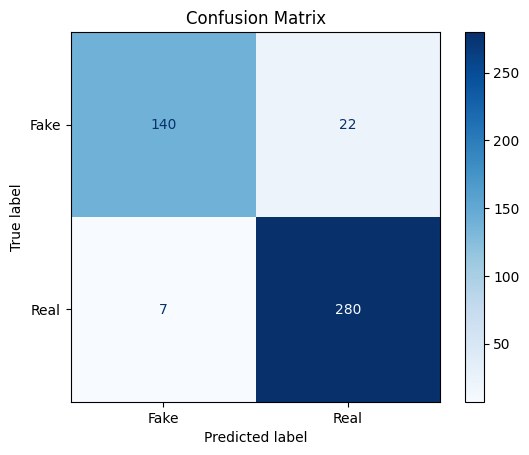

In [6]:
cm = confusion_matrix(all_labels, all_preds)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
disp.plot(cmap=plt.cm.Blues)
plt.title("Confusion Matrix")
plt.show()


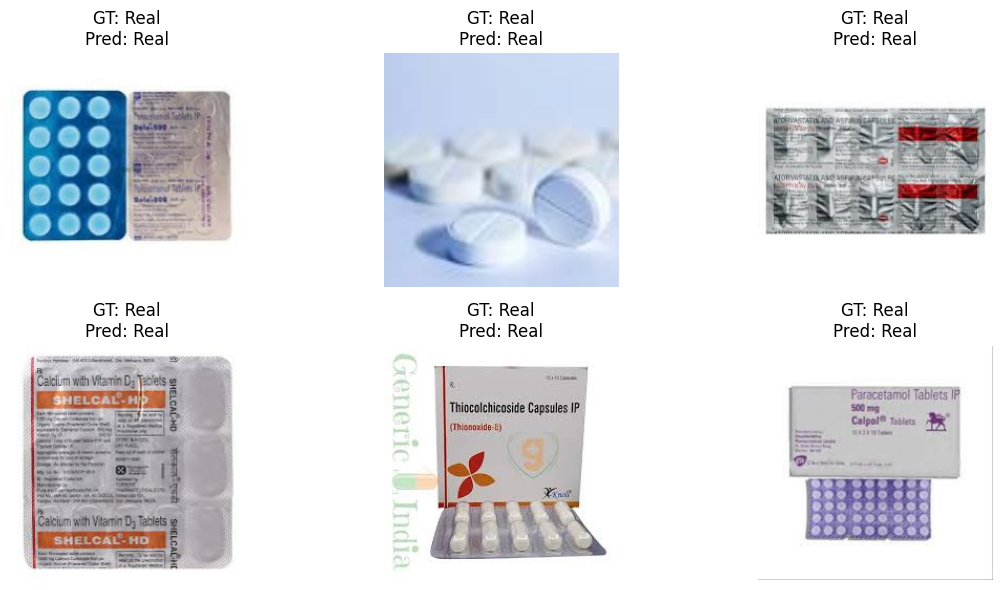

In [7]:
def unnormalize(img):
    mean = torch.tensor([0.485, 0.456, 0.406]).view(3,1,1)
    std = torch.tensor([0.229, 0.224, 0.225]).view(3,1,1)
    img = img * std + mean
    return img

import random
plt.figure(figsize=(12,6))

for i in range(6):
    idx = random.randint(0, len(test_dataset)-1)
    image, label = test_dataset[idx]
    image_input = image.unsqueeze(0).to(device)
    
    model.eval()
    with torch.no_grad():
        output = model(image_input)
        _, pred = torch.max(output, 1)
    
    image = unnormalize(image)
    plt.subplot(2,3,i+1)
    plt.imshow(image.permute(1,2,0))
    plt.title(f"GT: {class_names[label]}\nPred: {class_names[pred.item()]}")
    plt.axis("off")

plt.tight_layout()
plt.show()


In [8]:
from sklearn.metrics import classification_report


In [9]:
# Classification Report
report = classification_report(all_labels, all_preds, target_names=class_names, digits=4)
print("✅ Classification Report:\n")
print(report)


✅ Classification Report:

              precision    recall  f1-score   support

        Fake     0.9524    0.8642    0.9061       162
        Real     0.9272    0.9756    0.9508       287

    accuracy                         0.9354       449
   macro avg     0.9398    0.9199    0.9285       449
weighted avg     0.9363    0.9354    0.9347       449

